# Canopy Height Map in Dak Lak (Viet Nam) based on GEDI, Sentinel-1 and Sentinel-2 data

## 1. Importing packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
import lightgbm as lgb
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

## 2. Data Visualization

### Reading data

In [2]:
df = pd.read_csv("DakLak_train.csv")
df.head()

,VV_ascending,VH_ascending,VV_descending,VH_descending,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,rh95
0,0.789840,0.625815,0.934419,0.553235,0.2194,0.2554,0.2608,0.3191,0.3888,0.4169,0.4242,0.4579,0.5067,0.4402,11.98
1,0.860218,0.628940,0.591536,0.408909,0.1195,0.1603,0.1382,0.2553,0.4163,0.4870,0.5023,0.5319,0.4263,0.2627,12.70
2,0.703548,0.535121,0.814232,0.587804,0.1428,0.1870,0.1813,0.2745,0.4067,0.4619,0.5002,0.5121,0.5587,0.4338,7.11
3,0.670489,0.453182,0.652357,0.444775,0.1039,0.1516,0.1084,0.2232,0.4948,0.6260,0.6538,0.6607,0.3484,0.2015,2.43
4,0.679916,0.492881,0.668339,0.463933,0.1273,0.1754,0.1964,0.2981,0.4435,0.4981,0.5079,0.5440,0.5330,0.4235,3.22


### Basic properties of label

In [3]:
print("Number of samples: ", len(df))
print("Label details:")
df['rh95'].describe()

Number of samples:  127821
Label details:


,rh95
count,127821.000000
mean,8.949158
std,8.091093
min,1.830000
25%,2.870000
50%,5.720000
75%,12.690000
max,51.660000


### Label histogram

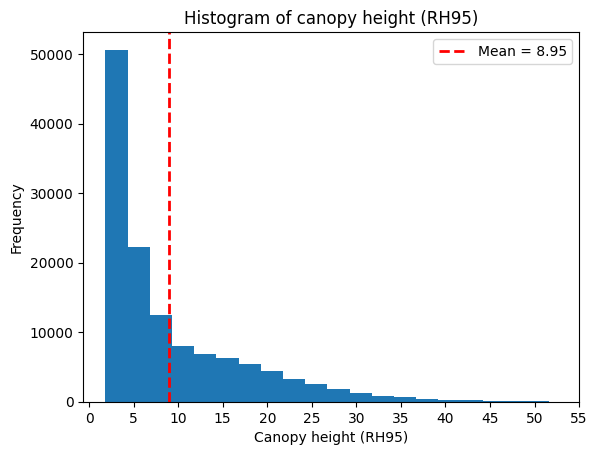

In [4]:
plt.hist(df['rh95'], bins=20)

xmin = df['rh95'].min()
xmax = df['rh95'].max()

plt.xticks(np.arange(0, xmax + 5, 5))
mean_val = df['rh95'].mean()
plt.axvline(mean_val, linestyle='--', linewidth=2, label=f"Mean = {mean_val:.2f}", c='r')
plt.xlabel("Canopy height (RH95)")
plt.ylabel("Frequency")
plt.title("Histogram of canopy height (RH95)")
plt.legend()
plt.show()

### Label density

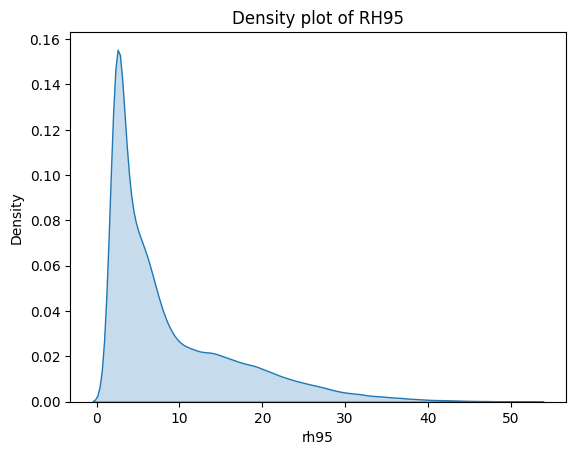

In [5]:
sns.kdeplot(df['rh95'], fill=True)
plt.title("Density plot of RH95")
plt.show()


## Correlation between features and label

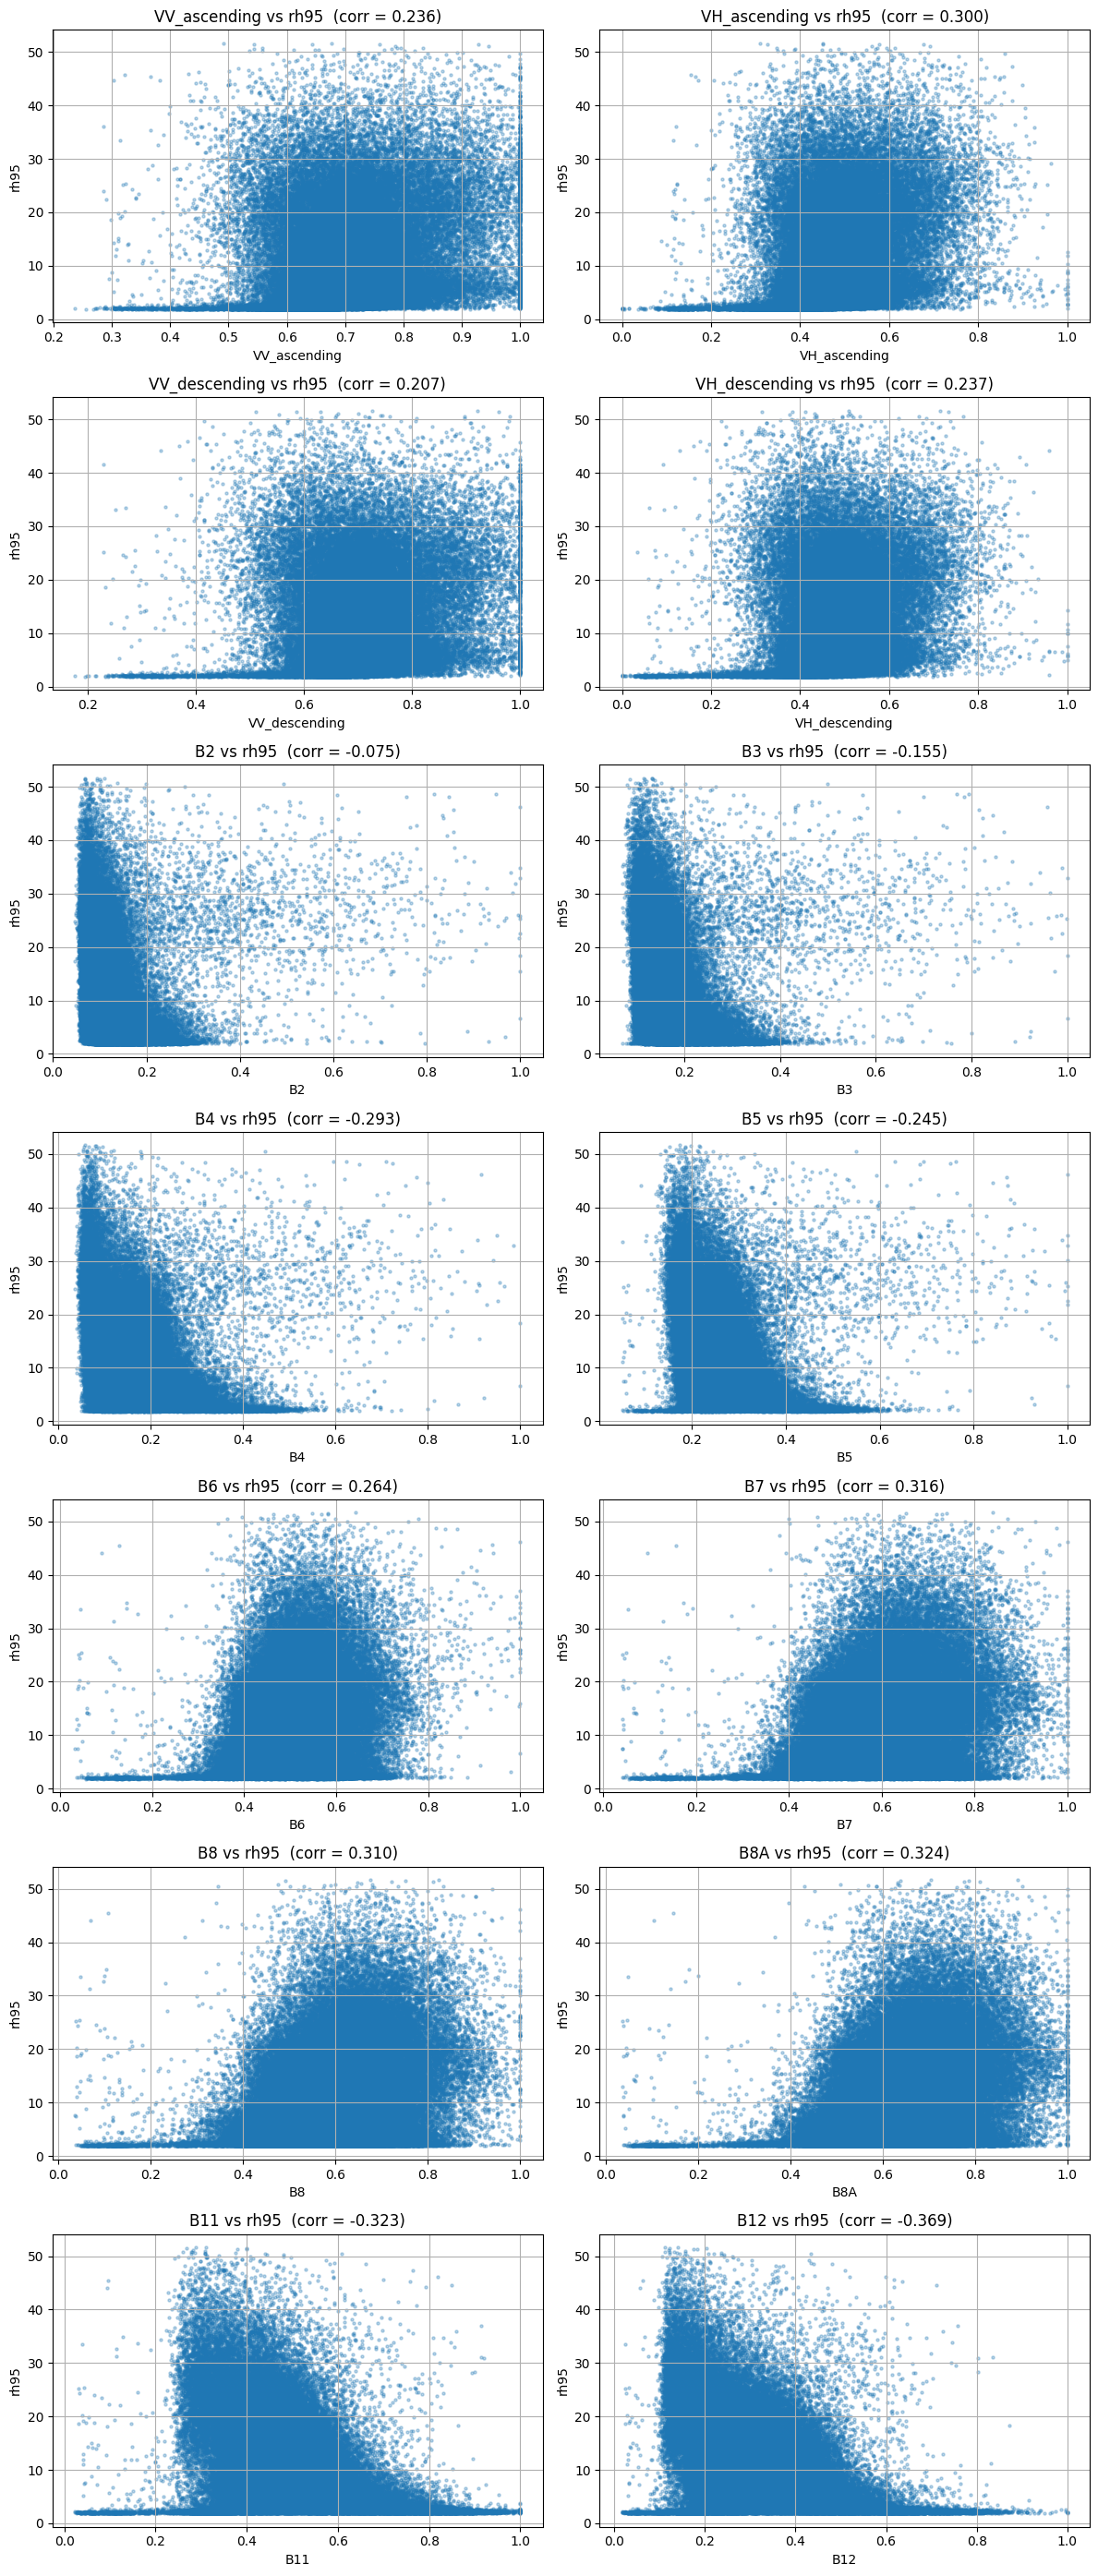

In [6]:
target = 'rh95'
features = [col for col in df.columns if col != target]

n_features = len(features)
cols = 2
rows = int(np.ceil(n_features / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]

    r = df[[target, col]].corr().iloc[0, 1]

    ax.scatter(df[col], df[target], alpha=0.3, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.set_title(f"{col} vs {target}  (corr = {r:.3f})")
    ax.grid(True)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Correlation heat map

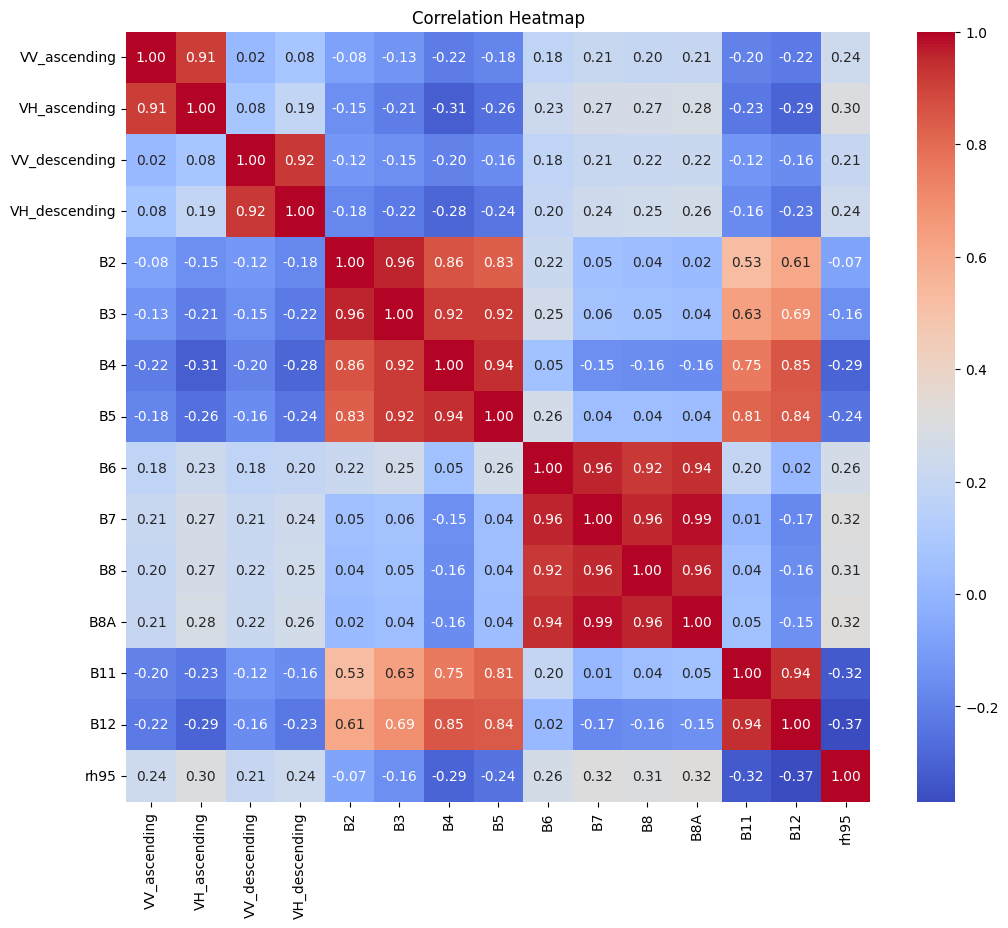

In [7]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### Box plot

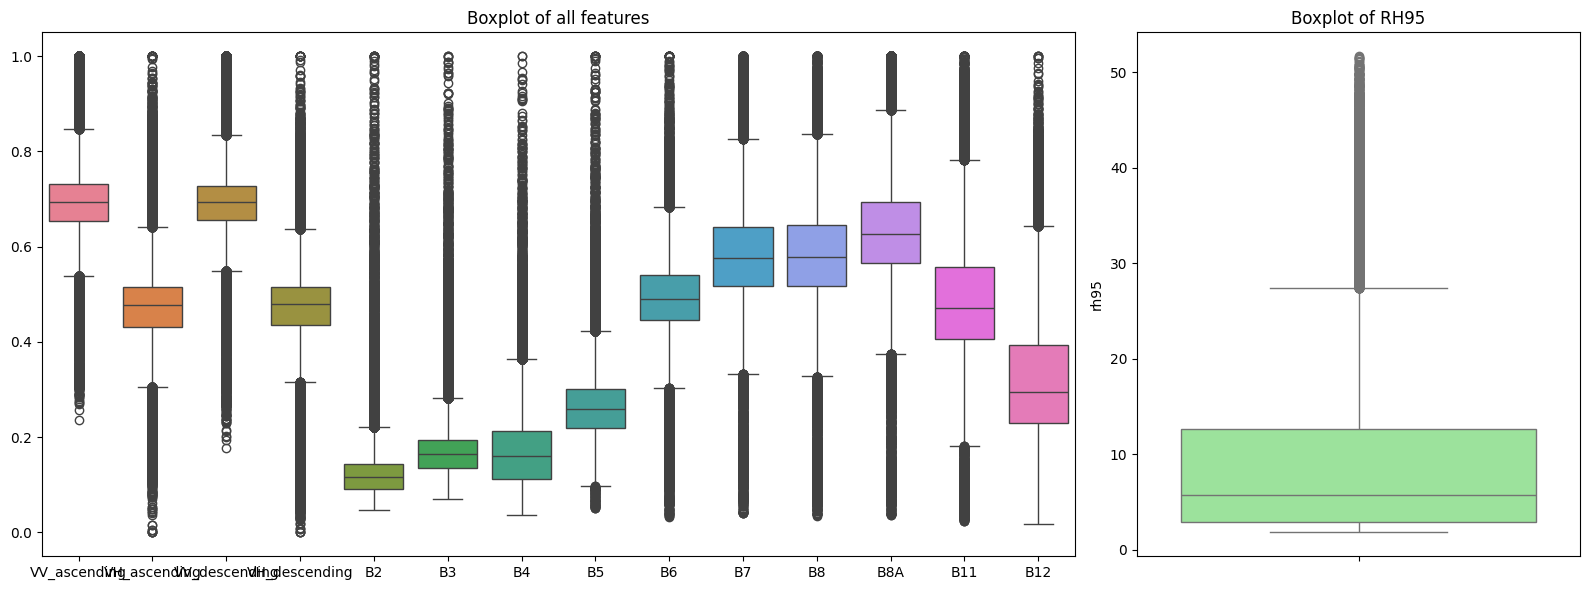

In [8]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16,6))
gs = GridSpec(1, 2, width_ratios=[7, 3], figure=fig)

ax0 = fig.add_subplot(gs[0])
sns.boxplot(data=df.drop(columns=['rh95']), ax=ax0)
ax0.set_title("Boxplot of all features")

ax1 = fig.add_subplot(gs[1])
sns.boxplot(y=df['rh95'], ax=ax1, color='lightgreen')
ax1.set_title("Boxplot of RH95")

plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [9]:
df['VH_to_VV_asc'] = df['VH_ascending'] / df['VV_ascending']
df['VH_to_VV_desc'] = df['VH_descending'] / df['VV_descending']
df['VV_diff'] = df['VV_ascending'] - df['VV_descending']
df['VH_diff'] = df['VH_ascending'] - df['VH_descending']
df['VV_mean'] = df[['VV_ascending','VV_descending']].mean(axis=1)
df['VH_mean'] = df[['VH_ascending','VH_descending']].mean(axis=1)
df['NDVI'] = (df['B8'] - df['B4']) / (df['B8'] + df['B4'])
df['EVI'] = 2.5 * (df['B8'] - df['B4']) / (df['B8'] + 6*df['B4'] - 7.5*df['B2'] + 1)
df['SAVI'] = ((df['B8'] - df['B4']) * (1 + 0.5)) / (df['B8'] + df['B4'] + 0.5)
df['GNDVI'] = (df['B8'] - df['B3']) / (df['B8'] + df['B3'])
df['MSAVI'] = (2 * df['B8'] + 1 - ((2 * df['B8'] + 1)**2 - 8 * (df['B8'] - df['B4']))**0.5) / 2

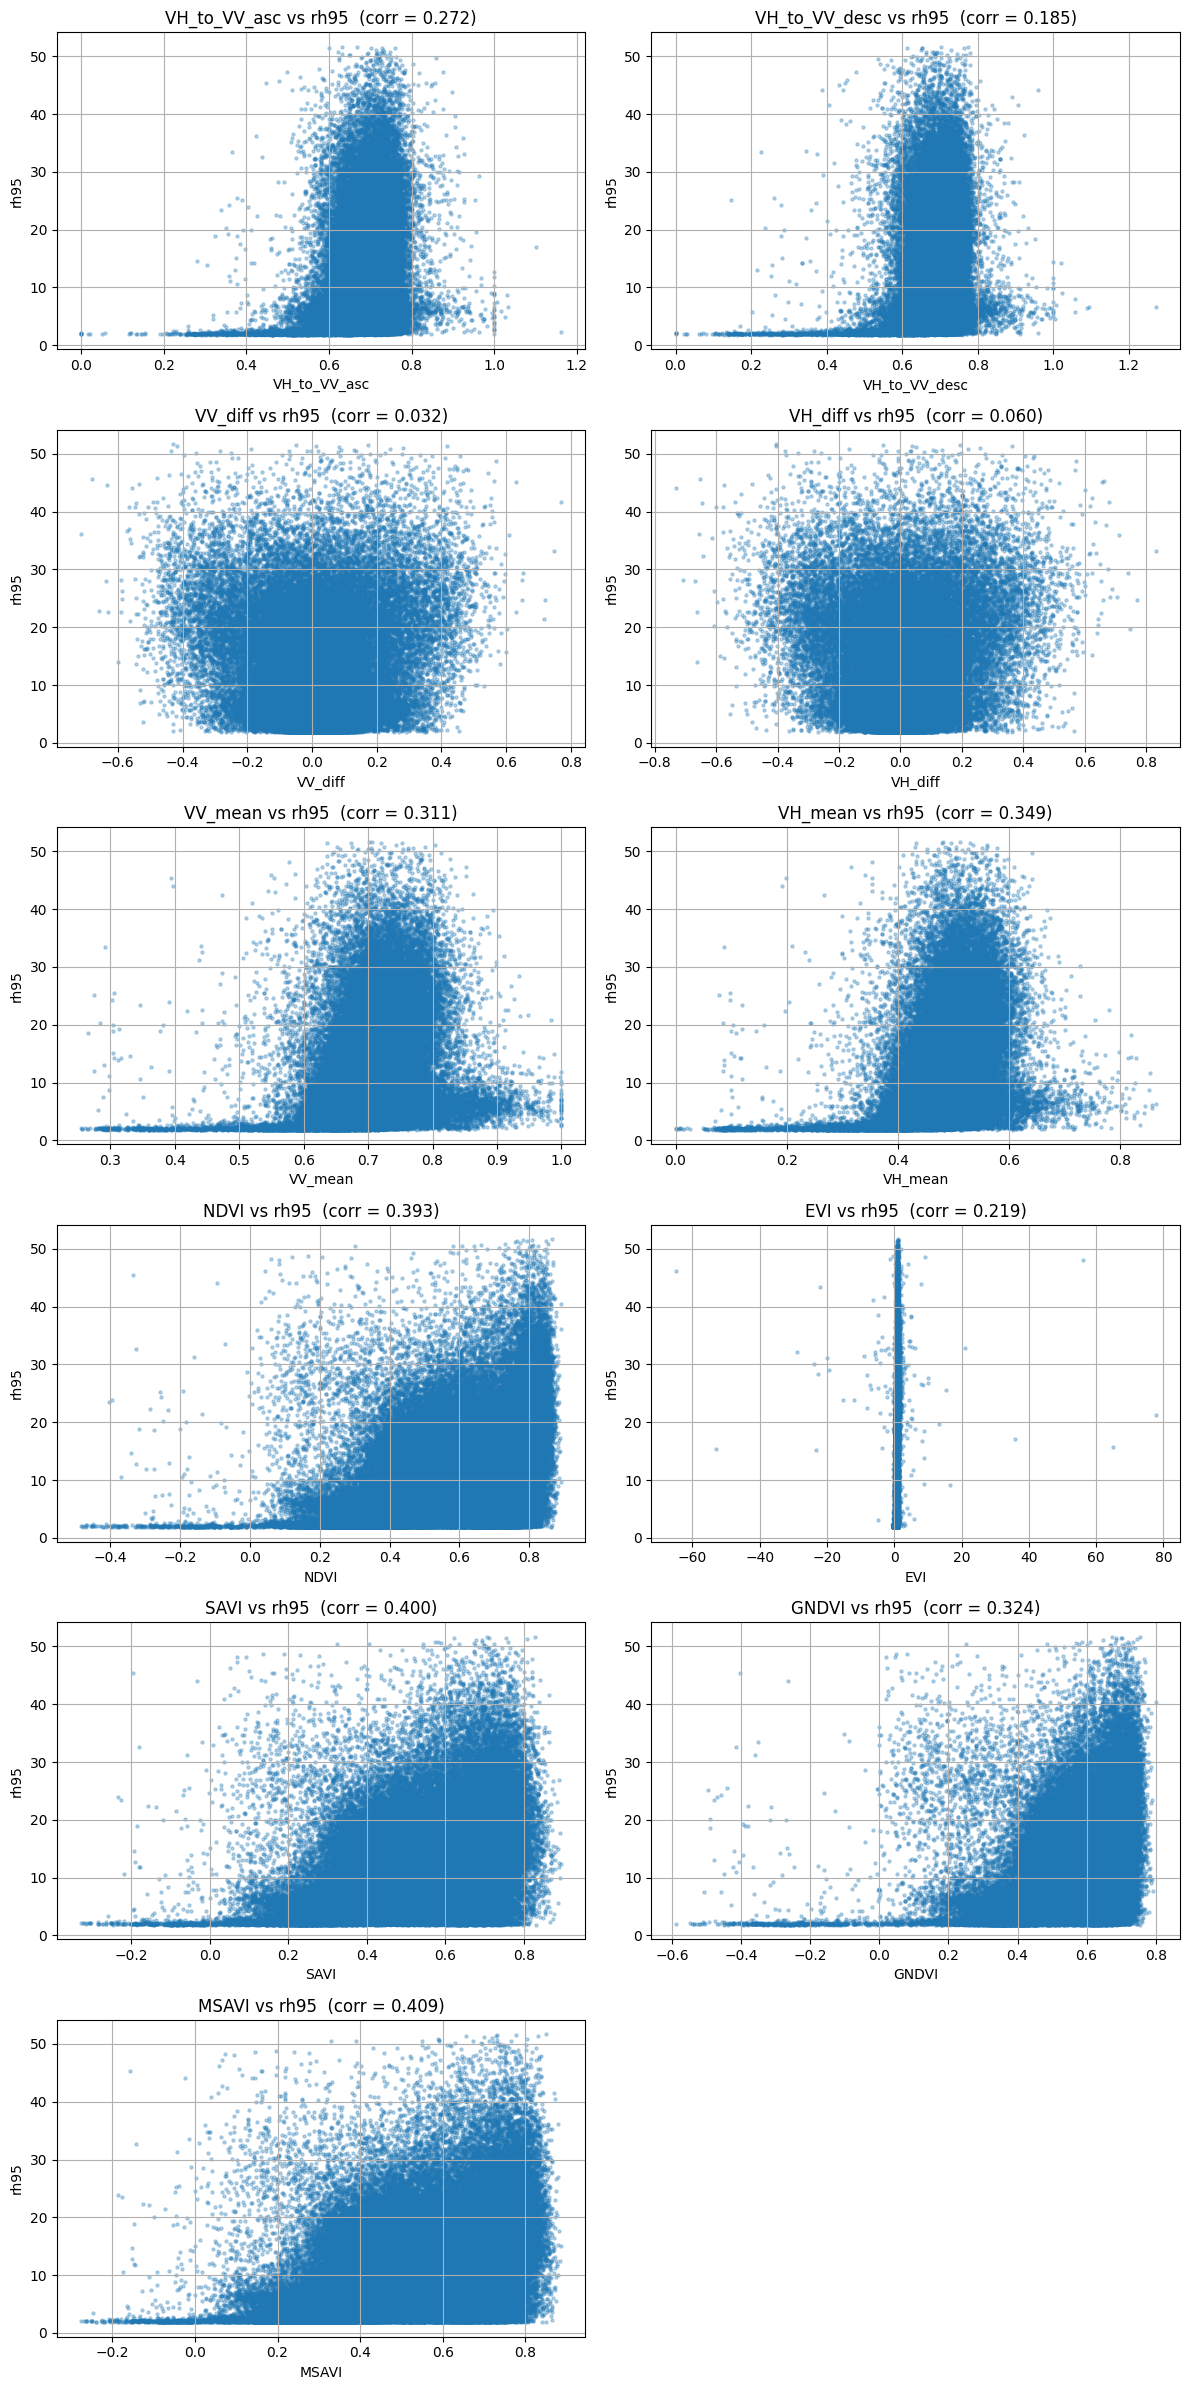

In [10]:
target = 'rh95'
features = [
    'VH_to_VV_asc',
    'VH_to_VV_desc',
    'VV_diff',
    'VH_diff',
    'VV_mean',
    'VH_mean',
    'NDVI',
    'EVI',
    'SAVI',
    'GNDVI',
    'MSAVI'
]

n_features = len(features)
cols = 2
rows = int(np.ceil(n_features / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]

    r = df[[target, col]].corr().iloc[0, 1]

    ax.scatter(df[col], df[target], alpha=0.3, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.set_title(f"{col} vs {target}  (corr = {r:.3f})")
    ax.grid(True)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 4. Training Machine Learning Models

### 4.1. LGBRegressor

In [11]:
corr_with_target = df.corr()['rh95']
# Features with low correlation
low_corr_features = corr_with_target[corr_with_target.abs() < 0].index.tolist()
low_corr_features

[]

In [12]:
df_train = df.drop(low_corr_features, axis=1)

In [13]:
def add_features(df):
    df = df.copy()

    df['VH_to_VV_asc'] = df['VH_ascending'] / df['VV_ascending']
    df['VH_to_VV_desc'] = df['VH_descending'] / df['VV_descending']
    df['VV_diff'] = df['VV_ascending'] - df['VV_descending']
    df['VH_diff'] = df['VH_ascending'] - df['VH_descending']
    df['VV_mean'] = df[['VV_ascending','VV_descending']].mean(axis=1)
    df['VH_mean'] = df[['VH_ascending','VH_descending']].mean(axis=1)

    df['NDVI'] = (df['B8'] - df['B4']) / (df['B8'] + df['B4'])
    df['EVI'] = 2.5 * (df['B8'] - df['B4']) / (df['B8'] + 6*df['B4'] - 7.5*df['B2'] + 1)
    df['SAVI'] = ((df['B8'] - df['B4']) * 1.5) / (df['B8'] + df['B4'] + 0.5)
    df['GNDVI'] = (df['B8'] - df['B3']) / (df['B8'] + df['B3'])
    df['MSAVI'] = (2*df['B8'] + 1 - ((2*df['B8'] + 1)**2 - 8*(df['B8'] - df['B4']))**0.5) / 2

    return df


In [ ]:
# Prepare training data
X = df_train.drop('rh95', axis=1)
y = df_train['rh95']

# Define model
model = lgb.LGBMRegressor(device='gpu', n_jobs=-1)

# Define hyperparameter grid
param_grid = {
    'num_leaves': [63, 127, 256],
    'max_depth': [12, 16, 20],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [500, 900, 1200],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Use RMSE as scoring
mae_score = make_scorer(lambda y_true, y_pred: mean_absolute_error(y_true, y_pred), greater_is_better=False)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    scoring=mae_score,
    cv=5,
    verbose=2,
    random_state=42,
    refit=True
)

random_search.fit(X, y)

print("Best parameters:", random_search.best_params_)
print("Best CV MAE:", -random_search.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 107688, number of used features: 25


[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5060 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 25 dense feature groups (2.88 MB) transferred to GPU in 0.007570 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 9.436694
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=16, min_child_samples=20, n_estimators=900, num_leaves=63, subsample=0.8; total time=   5.7s
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 107688, number of used features: 25
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5060 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info

In [14]:
df = pd.read_csv("DakLak_train.csv")

X = df.drop(["rh95", "B8"], axis=1)
y = df['rh95']

In [15]:
df_test = pd.read_csv("DakLak_test.csv")
df_test['VH_to_VV_asc'] = df_test['VH_ascending'] / df_test['VV_ascending']
df_test['VH_to_VV_desc'] = df_test['VH_descending'] / df_test['VV_descending']
df_test['VV_diff'] = df_test['VV_ascending'] - df_test['VV_descending']
df_test['VH_diff'] = df_test['VH_ascending'] - df_test['VH_descending']
df_test['VV_mean'] = df_test[['VV_ascending','VV_descending']].mean(axis=1)
df_test['VH_mean'] = df_test[['VH_ascending','VH_descending']].mean(axis=1)
df_test['NDVI'] = (df_test['B8'] - df_test['B4']) / (df_test['B8'] + df_test['B4'])
df_test['EVI'] = 2.5 * (df_test['B8'] - df_test['B4']) / (df_test['B8'] + 6*df_test['B4'] - 7.5*df_test['B2'] + 1)
df_test['SAVI'] = ((df_test['B8'] - df_test['B4']) * (1 + 0.5)) / (df_test['B8'] + df_test['B4'] + 0.5)
df_test['GNDVI'] = (df_test['B8'] - df_test['B3']) / (df_test['B8'] + df_test['B3'])
df_test['MSAVI'] = (2 * df_test['B8'] + 1 - ((2 * df_test['B8'] + 1)**2 - 8 * (df_test['B8'] - df_test['B4']))**0.5) / 2
df_test = df_test.drop(low_corr_features, axis=1)

In [16]:
df_train = pd.read_csv('DakLak_train.csv')
df_test = pd.read_csv('DakLak_test.csv')

**LightGBM best params**

In [17]:
best_params = {
    'subsample': 1.0,
    'num_leaves': 256,
    'n_estimators': 1200,
    'min_child_samples': 5,
    'max_depth': 20,
    'learning_rate': 0.01,
    'colsample_bytree': 0.7,
    'n_jobs': -1,
    'random_state': 42
}

In [18]:
df = add_features(df)
df_test = add_features(df_test)
df = df.drop(low_corr_features, axis=1)
df_test = df_test.drop(low_corr_features, axis=1)

In [19]:
X_train = df.drop('rh95', axis=1)
y_train = df['rh95']

X_test = df_test.drop('rh95', axis=1)
y_test = df_test['rh95']

**Weighted Training**

In [25]:
from sklearn.model_selection import train_test_split

#print("Đang training với trọng số (Weighted Training)...")
model = lgb.LGBMRegressor(**best_params)
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)
weights_sub = np.ones(len(y_train_sub))
weights_sub[y_train_sub > 20] = 3.0
model.fit(
    X_train_sub,
    y_train_sub,
    sample_weight=weights_sub,
    eval_set=[(X_val, y_val)],
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

# 5. Dự báo
y_pred = model.predict(X_test)
y_pred_final = y_pred.copy()

# 6. Đánh giá kết quả
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n--- KẾT QUẢ ---")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

mask_high = y_test > 20
if mask_high.sum() > 0:
    mae_high = mean_absolute_error(y_test[mask_high], y_pred[mask_high])
    r2_high = r2_score(y_test[mask_high], y_pred[mask_high])
    print("\n--- KẾT QUẢ NHÓM > 20m (Sau khi Weighted) ---")
    print(f"MAE High: {mae_high:.4f}")
    print(f"R2 High:  {r2_high:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.073762 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 102256, number of used features: 25
[LightGBM] [Info] Start training from score 12.227363
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 5.02395	valid_0's l2: 36.9356
[200]	valid_0's l1: 4.22527	valid_0's l2: 30.8533
[300]	valid_0's l1: 3.94788	valid_0's l2: 29.6311
[400]	valid_0's l1: 3.83523	valid_0's l2: 29.2047
[500]	valid_0's l1: 3.78517	valid_0's l2: 28.9007
[600]	valid_0's l1: 3.75524	valid_0's l2: 28.6946
[700]	valid_0's l1: 3.73287	valid_0's l2: 28.5232
[800]	valid_0's l1: 3.71684	valid_0's l2: 28.3927
[900]	valid_0's l1: 3.7033	valid_0's l2: 28.2796
[1000]	valid_0's l1: 3.68979	valid_0's l2: 28.1706
[1100]	valid_0's l1: 3.67799	valid_0's l2: 28.0835
[1200]	valid_0's l1: 3.66692	valid_0's l2: 

In [ ]:
# Xác định cột Target (nhãn) và Features
target_col = 'rh95'
feature_cols = [c for c in df_train.columns if c != target_col]

# Tách X, y
X_train_raw = df_train[feature_cols]
y_train_raw = df_train[target_col]
X_test_raw = df_test[feature_cols]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

**Autoencoder**

In [ ]:
print(f"Số lượng mẫu Train ban đầu: {len(df_train)}")

print("\n[Đang chạy] Autoencoder để lọc nhiễu...")
input_dim = X_train_scaled.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(int(input_dim/2), activation='relu')(input_layer)
encoded = Dense(int(input_dim/4), activation='relu')(encoded)
decoded = Dense(int(input_dim/2), activation='relu')(encoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=50, batch_size=32, verbose=0)

# Tính lỗi tái tạo
reconstructions = autoencoder.predict(X_train_scaled)
mse = np.mean(np.power(X_train_scaled - reconstructions, 2), axis=1)
threshold = np.percentile(mse, 98)

mask_clean = mse < threshold
X_train_clean = X_train_raw[mask_clean]
y_train_clean = y_train_raw[mask_clean]
print(f"-> Đã loại bỏ {(~mask_clean).sum()} mẫu nhiễu bằng Autoencoder.")

print(f"\n[Training] Bắt đầu train LightGBM với {len(X_train_clean)} mẫu sạch...")

model = lgb.LGBMRegressor(**best_params)

model.fit(X_train_clean, y_train_clean)

y_pred_test = model.predict(X_test_raw)

df_test['predicted_rh95'] = y_pred_test

if target_col in df_test.columns:
    from sklearn.metrics import mean_absolute_error, r2_score
    y_true = df_test[target_col]
    mae = mean_absolute_error(y_true, y_pred_test)
    r2 = r2_score(y_true, y_pred_test)

    print("\n--- KẾT QUẢ TRÊN TẬP TEST ---")
    print(f"MAE: {mae:.4f}")
    print(f"R2 : {r2:.4f}")
else:
    print("\nĐã dự báo xong. File test không có nhãn thực tế để so sánh.")

Số lượng mẫu Train ban đầu: 127821

[Đang chạy] Autoencoder để lọc nhiễu...
3995/3995 ━━━━━━━━━━━━━━━━━━━━ 3s 668us/step
-> Đã loại bỏ 2557 mẫu nhiễu bằng Autoencoder.

[Training] Bắt đầu train LightGBM với 125264 mẫu sạch...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012756 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 125264, number of used features: 14
[LightGBM] [Info] Start training from score 8.856548

--- KẾT QUẢ TRÊN TẬP TEST ---
MAE: 3.4473
R2 : 0.6828
Đã lưu kết quả ra file 'submission_cleaned.csv'


**Quantile Regression**

In [ ]:
from sklearn.model_selection import train_test_split

quantile_params = best_params.copy()
quantile_params.update({
    'objective': 'quantile',
    'alpha': 0.75,
    'metric': 'quantile'
})

print("Đang training Quantile Regression (alpha=0.75) trên dữ liệu GỐC...")
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)
model_q = lgb.LGBMRegressor(**quantile_params)

model_q.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)],
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

# 3. Đánh giá
y_pred_q = model_q.predict(X_test)

# Tổng thể
print("\n--- KẾT QUẢ TỔNG THỂ (Quantile) ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_q):.4f}")
print(f"R2:   {r2_score(y_test, y_pred_q):.4f}")

# Nhóm cao
mask_high = y_test > 20
if mask_high.sum() > 0:
    print("\n--- KẾT QUẢ NHÓM > 20m ---")
    print(f"MAE High: {mean_absolute_error(y_test[mask_high], y_pred_q[mask_high]):.4f}")
    print(f"R2 High:  {r2_score(y_test[mask_high], y_pred_q[mask_high]):.4f}")

Đang training Quantile Regression (alpha=0.75) trên dữ liệu GỐC...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026762 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 102256, number of used features: 25
[LightGBM] [Info] Start training from score 12.690000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 5.28974	valid_0's quantile: 1.95377
[200]	valid_0's l1: 4.56151	valid_0's quantile: 1.69395
[300]	valid_0's l1: 4.31848	valid_0's quantile: 1.62045
[400]	valid_0's l1: 4.22086	valid_0's quantile: 1.59668
[500]	valid_0's l1: 4.17704	valid_0's quantile: 1.58778
[600]	valid_0's l1: 4.15582	valid_0's quantile: 1.58351
[700]	valid_0's l1: 4.14632	valid_0's quantile: 1.58196
[800]	valid_0's l1: 4.13598	valid_0's quantile: 1.5799
[900]	valid_0's l1: 4.12551	valid_0's quantile: 1.57763
[1000]	valid_0's l1: 4.1

In [ ]:
print(X_train.shape)
print(X_train.columns.tolist())

(127821, 14)
['VV_ascending', 'VH_ascending', 'VV_descending', 'VH_descending', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']


**Ensemble, 40% LGBM, 60% Quantile Regression**

In [ ]:
print("Training lại model mặc định để Ensemble...")

model_default = lgb.LGBMRegressor(**best_params)
model_default.fit(X_train, y_train)

pred_default = model_default.predict(X_test)
pred_quantile = model_q.predict(X_test)

model_weighted = lgb.LGBMRegressor(**best_params)

model_weighted.fit(X_train, y_train, sample_weight=weights)

# Dự báo
pred_weighted = model_weighted.predict(X_test)
pred_quantile = model_q.predict(X_test)

# Kết hợp (Tỷ lệ 40% Default - 60% Quantile)
y_pred_ensemble = (0.4 * pred_default) + (0.6 * pred_quantile)
#y_pred_ensemble = (0.4 * pred_weighted) + (0.6 * pred_quantile)
# Đánh giá Ensemble
print("\n--- KẾT QUẢ ENSEMBLE (Kết hợp 40/60) ---")

# Đánh giá Tổng thể
mae = mean_absolute_error(y_test, y_pred_ensemble)
mse = mean_squared_error(y_test, y_pred_ensemble)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ensemble)

print(f"MAE Tổng:  {mae:.4f}")
print(f"RMSE Tổng: {rmse:.4f}")
print(f"R2 Tổng:   {r2:.4f}")

# Đánh giá Nhóm cao (>20m)
mask_high = y_test > 20
if mask_high.sum() > 0:
    y_true_high = y_test[mask_high]
    y_pred_high = y_pred_ensemble[mask_high]

    mae_high = mean_absolute_error(y_true_high, y_pred_high)
    mse_high = mean_squared_error(y_true_high, y_pred_high)
    rmse_high = np.sqrt(mse_high)
    r2_high = r2_score(y_true_high, y_pred_high)

    print("\n--- NHÓM CÂY CAO (> 20m) ---")
    print(f"MAE High:  {mae_high:.4f}")
    print(f"RMSE High: {rmse_high:.4f}")
    print(f"R2 High:   {r2_high:.4f}")
else:
    print("\nKhông có mẫu > 20m trong tập test.")

Training lại model mặc định để Ensemble...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033343 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 127821, number of used features: 25
[LightGBM] [Info] Start training from score 8.949158
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033865 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 127821, number of used features: 25
[LightGBM] [Info] Start training from score 12.231482

--- KẾT QUẢ ENSEMBLE (Kết hợp 40/60) ---
MAE Tổng:  3.4023
RMSE Tổng: 5.1882
R2 Tổng:   0.7076

--- NHÓM CÂY CAO (> 20m) ---
MAE High:  7.0612
RMSE High: 8.9766
R2 High:   -0.8219


**Oversampling**

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
print(f"Tổng mẫu tập Train gốc (df): {len(df)}")
print(f"Tổng mẫu tập Test gốc (df_test): {len(df_test)}")
df_train_sub, df_val = train_test_split(df, test_size=0.2, random_state=42)
print(f"-> Train sub (để oversample): {len(df_train_sub)}")
print(f"-> Validation (để early stop): {len(df_val)}")

train_high = df_train_sub[df_train_sub['rh95'] > 20]
train_low = df_train_sub[df_train_sub['rh95'] <= 20]

train_high_oversampled = pd.concat([train_high] * 4, axis=0)
df_train_balanced = pd.concat([train_low, train_high, train_high_oversampled], axis=0)
df_train_balanced = shuffle(df_train_balanced, random_state=42)

print(f"-> Train sub sau khi Oversampling: {len(df_train_balanced)}")

feature_cols = [c for c in df.columns if c != 'rh95']

X_train_final = df_train_balanced[feature_cols]
y_train_final = df_train_balanced['rh95']

X_val = df_val[feature_cols]
y_val = df_val['rh95']

X_test = df_test[feature_cols]
y_test = df_test['rh95']

print("\nĐang training mô hình LightGBM...")

model = lgb.LGBMRegressor(**best_params)
model.fit(
    X_train_final,
    y_train_final,
    eval_set=[(X_val, y_val)],
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n=== KẾT QUẢ FINAL TRÊN TẬP TEST (Độc lập hoàn toàn) ===")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")
# Nhóm cao > 20m
mask_high = y_test > 20
if mask_high.sum() > 0:
    mae_high = mean_absolute_error(y_test[mask_high], y_pred[mask_high])
    r2_high = r2_score(y_test[mask_high], y_pred[mask_high])

    print("\n--- KẾT QUẢ NHÓM > 20m (TEST) ---")
    print(f"MAE High: {mae_high:.4f}")
    print(f"R2 High:  {r2_high:.4f}")
else:
    print("\nKhông có mẫu > 20m trong tập Test.")

Tổng mẫu tập Train gốc (df): 127821
Tổng mẫu tập Test gốc (df_test): 19958
-> Train sub (để oversample): 102256
-> Validation (để early stop): 25565
-> Train sub sau khi Oversampling: 148440

Đang training mô hình LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.097387 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 148440, number of used features: 25
[LightGBM] [Info] Start training from score 14.486691
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 5.62099	valid_0's l2: 43.0101
[200]	valid_0's l1: 4.58574	valid_0's l2: 34.3825
[300]	valid_0's l1: 4.21209	valid_0's l2: 32.46
[400]	valid_0's l1: 4.05419	valid_0's l2: 31.68
[500]	valid_0's l1: 3.9808	valid_0's l2: 31.1571
[600]	valid_0's l1: 3.93857	valid_0's l2: 30.7972
[700]	valid_0's l1: 3.9112	valid_0's l2: 30.5366
[800]	valid_0's l1: 3.88

**Baseline**

In [ ]:
model = lgb.LGBMRegressor(**best_params)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_final = y_pred.copy()


mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n--- KẾT QUẢ ---")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037277 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 127821, number of used features: 25
[LightGBM] [Info] Start training from score 8.949158

--- KẾT QUẢ ---
MAE:  3.3953
RMSE: 5.3347
R2:   0.6909


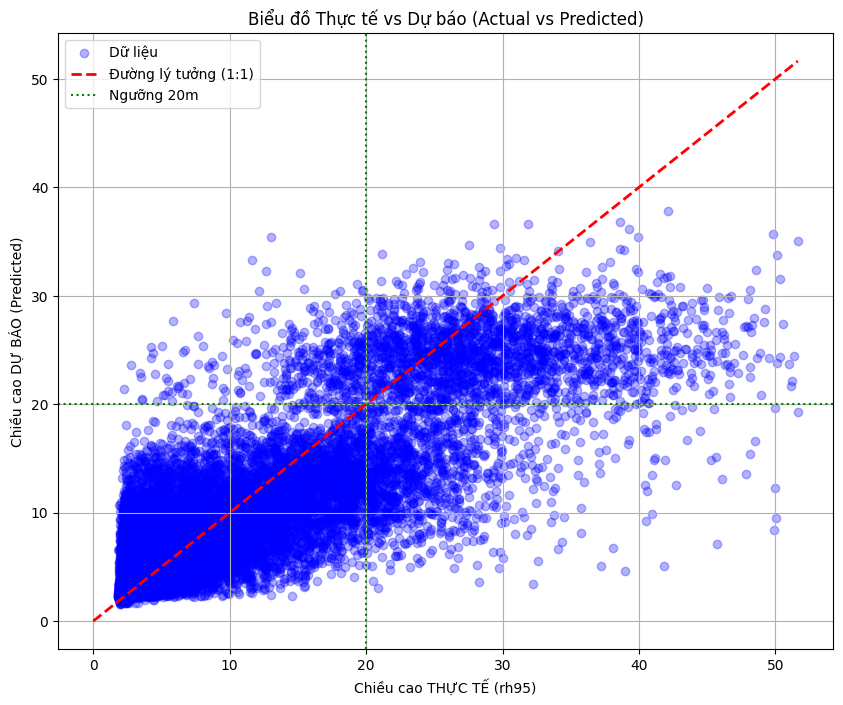

In [ ]:
plt.figure(figsize=(10, 8))

# Vẽ điểm dữ liệu
# Dùng alpha=0.3 để thấy mật độ điểm nếu dữ liệu quá dày
plt.scatter(y_test, y_pred, alpha=0.3, color='blue', label='Dữ liệu')

# Vẽ đường kỳ vọng 1:1 (Dự đoán hoàn hảo)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Đường lý tưởng (1:1)')

# Vẽ đường ngưỡng 20m để dễ so sánh
plt.axvline(x=20, color='green', linestyle=':', label='Ngưỡng 20m')
plt.axhline(y=20, color='green', linestyle=':')

plt.xlabel('Chiều cao THỰC TẾ (rh95)')
plt.ylabel('Chiều cao DỰ BÁO (Predicted)')
plt.title('Biểu đồ Thực tế vs Dự báo (Actual vs Predicted)')
plt.legend()
plt.grid(True)
plt.show()

**Phân tích giá trị trên 20 và dưới 20m**

In [ ]:
# Tạo mask để lọc dữ liệu
mask_high = y_test > 20
mask_low = y_test <= 20

# --- NHÓM 1: Cây cao > 20m ---
if mask_high.sum() > 0:
    y_test_high = y_test[mask_high]
    y_pred_high = y_pred[mask_high]

    mae_high = mean_absolute_error(y_test_high, y_pred_high)
    rmse_high = np.sqrt(mean_squared_error(y_test_high, y_pred_high))
    r2_high = r2_score(y_test_high, y_pred_high)

    print("\n=== KẾT QUẢ NHÓM CÂY > 20m ===")
    print(f"Số lượng mẫu: {mask_high.sum()}")
    print(f"MAE:  {mae_high:.4f}")
    print(f"RMSE: {rmse_high:.4f}")
    print(f"R2:   {r2_high:.4f}")
else:
    print("\n=== NHÓM CÂY > 20m: Không có dữ liệu ===")

# --- NHÓM 2: Cây thấp <= 20m ---
if mask_low.sum() > 0:
    y_test_low = y_test[mask_low]
    y_pred_low = y_pred[mask_low]

    mae_low = mean_absolute_error(y_test_low, y_pred_low)
    rmse_low = np.sqrt(mean_squared_error(y_test_low, y_pred_low))
    r2_low = r2_score(y_test_low, y_pred_low)

    print("\n=== KẾT QUẢ NHÓM CÂY <= 20m ===")
    print(f"Số lượng mẫu: {mask_low.sum()}")
    print(f"MAE:  {mae_low:.4f}")
    print(f"RMSE: {rmse_low:.4f}")
    print(f"R2:   {r2_low:.4f}")
else:
    print("\n=== NHÓM CÂY <= 20m: Không có dữ liệu ===")


=== KẾT QUẢ NHÓM CÂY > 20m ===
Số lượng mẫu: 3209
MAE:  8.5225
RMSE: 10.5105
R2:   -1.4977

=== KẾT QUẢ NHÓM CÂY <= 20m ===
Số lượng mẫu: 16749
MAE:  2.4691
RMSE: 3.6713
R2:   0.4545


In [ ]:
model = random_search.best_estimator_
model

,boosting_type,'gbdt'
,num_leaves,256
,max_depth,20
,learning_rate,0.01
,n_estimators,1200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,5


In [ ]:
X_test = df_test.drop("rh95", axis=1)
y_test = df_test['rh95']

y_pred = model.predict(X_test)
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))

MAE:  3.4424272411724526
RMSE:  5.392005668487491
R2:  0.6842191053527967


In [26]:
mask_super_high = y_test > 80
num_super_high_trees = mask_super_high.sum()
total_test_samples = len(y_test)

if total_test_samples > 0:
    percentage_super_high = (num_super_high_trees / total_test_samples) * 100
    print(f"Percentage of trees with actual height > 80m in the test set: {percentage_super_high:.2f}%")
else:
    print("No samples in the test set.")

Percentage of trees with actual height > 80m in the test set: 0.00%


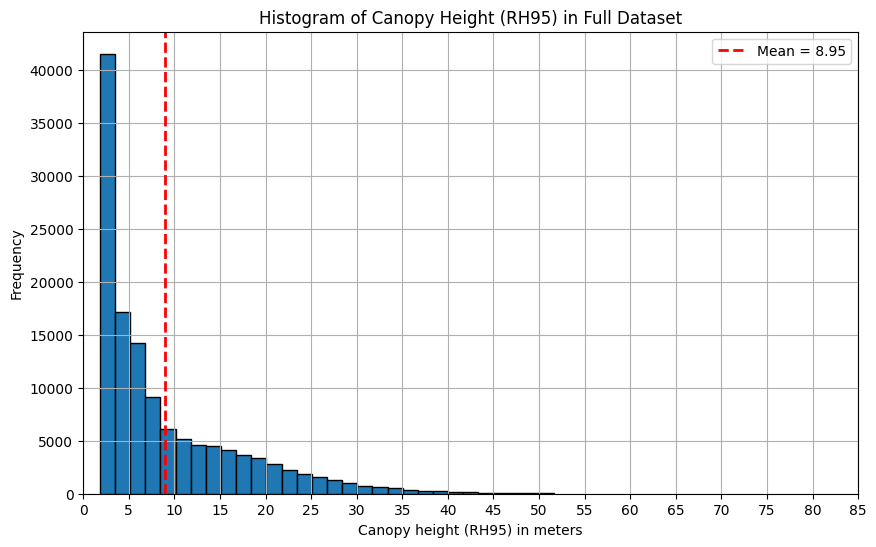

In [30]:
plt.figure(figsize=(10, 6))
plt.hist(df['rh95'], bins=30, edgecolor='black')

# Set x-axis limits to clearly show up to and beyond 80m
# Use the actual max value from the data or a predefined limit like 80
max_rh95_val = df['rh95'].max()
plt.xlim(0, max(max_rh95_val + 5, 85)) # Ensure x-axis goes at least to 85 to illustrate the point

plt.xticks(np.arange(0, plt.xlim()[1] + 5, 5))

mean_val = df['rh95'].mean()
plt.axvline(mean_val, linestyle='--', linewidth=2, label=f"Mean = {mean_val:.2f}", c='r')
plt.xlabel("Canopy height (RH95) in meters")
plt.ylabel("Frequency")
plt.title("Histogram of Canopy Height (RH95) in Full Dataset")
plt.legend()
plt.grid(True)
plt.show()

**Train với Isolation Forest**

In [ ]:
print(f"Số lượng mẫu Train ban đầu: {len(df_train)}")

print("\n[Đang chạy] Isolation Forest để lọc nhiễu...")
iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
train_anomaly_labels = iso.fit_predict(X_train_scaled)

mask_clean = train_anomaly_labels == 1
X_train_clean = X_train_raw[mask_clean]
y_train_clean = y_train_raw[mask_clean]

print(f"-> Đã loại bỏ {(~mask_clean).sum()} mẫu nhiễu bằng Isolation Forest.")

model = lgb.LGBMRegressor(**best_params)

model.fit(X_train_clean, y_train_clean)

y_pred_test = model.predict(X_test_raw)

df_test['predicted_rh95'] = y_pred_test

if target_col in df_test.columns:
    from sklearn.metrics import mean_absolute_error, r2_score
    y_true = df_test[target_col]
    mae = mean_absolute_error(y_true, y_pred_test)
    r2 = r2_score(y_true, y_pred_test)

    print("\n--- KẾT QUẢ TRÊN TẬP TEST ---")
    print(f"MAE: {mae:.4f}")
    print(f"R2 : {r2:.4f}")
else:
    print("\nĐã dự báo xong. File test không có nhãn thực tế để so sánh.")


Số lượng mẫu Train ban đầu: 127821

[Đang chạy] Isolation Forest để lọc nhiễu...
-> Đã loại bỏ 6391 mẫu nhiễu bằng Isolation Forest.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 121430, number of used features: 14
[LightGBM] [Info] Start training from score 8.805072

--- KẾT QUẢ TRÊN TẬP TEST ---
MAE: 3.5449
R2 : 0.6625


### 4.2. XGBoost

In [ ]:
import xgboost as xgb

param_dist = {
    'n_estimators': [500, 800, 1000, 1200],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8, 10],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

# Use RMSE as the scoring metric
mae_score = make_scorer(lambda y_true, y_pred: mean_absolute_error(y_true, y_pred), greater_is_better=False)

# Initialize XGBoost regressor
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    n_jobs=-1
)

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring=mae_score,
    cv=5,
    verbose=2,
    random_state=42,
    refit=True
)

random_search.fit(X, y)
print("Best parameters:", random_search.best_params_)
print("Best CV MAE:", -random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=10, min_child_weight=5, n_estimators=1200, reg_alpha=0.1, reg_lambda=1, subsample=0.8; total time=  13.5s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=10, min_child_weight=5, n_estimators=1200, reg_alpha=0.1, reg_lambda=1, subsample=0.8; total time=  13.6s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=10, min_child_weight=5, n_estimators=1200, reg_alpha=0.1, reg_lambda=1, subsample=0.8; total time=  13.7s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=10, min_child_weight=5, n_estimators=1200, reg_alpha=0.1, reg_lambda=1, subsample=0.8; total time=  13.6s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=10, min_child_weight=5, n_estimators=1200, reg_alpha=0.1, reg_lambda=1, subsample=0.8; total time=  13.8s
[CV] END colsample_bytree=1.0, gamma=0.5, learni

In [ ]:
model = random_search.best_estimator_
model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
y_pred = model.predict(X_test)
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))


MAE:  3.60657236825847
RMSE:  5.4423384136395185
R2:  0.6744735729886302


### 4.3. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf = RandomForestRegressor(
    n_estimators=200,   # number of trees
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    max_features='sqrt',
    verbose=1
)

# Train
rf.fit(X, y)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 11 concurrent workers.


[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:   16.1s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   17.8s finished


,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Make predictions
y_pred = rf.predict(X)

# Evaluate
print("MAE:", mean_absolute_error(y, y_pred))
print("RMSE:", root_mean_squared_error(y, y_pred))
print("R2:", r2_score(y, y_pred))

[Parallel(n_jobs=11)]: Using backend ThreadingBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done  28 tasks      | elapsed:    0.1s


MAE: 3.481292764448733
RMSE: 4.7981947674008145
R2: 0.7056427017083933


[Parallel(n_jobs=11)]: Done 178 tasks      | elapsed:    0.3s
[Parallel(n_jobs=11)]: Done 200 out of 200 | elapsed:    0.3s finished


In [ ]:
y_pred = rf.predict(X_test)
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))


MAE:  3.850971915780239
RMSE:  5.664533885301627
R2:  0.6473502967605789


[Parallel(n_jobs=11)]: Using backend ThreadingBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=11)]: Done 178 tasks      | elapsed:    0.1s
[Parallel(n_jobs=11)]: Done 200 out of 200 | elapsed:    0.1s finished


## 5. Training Deep Learning Models

In [ ]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device: ", device)
print("Version: ", torch.__version__)

Device:  cuda
Version:  2.10.0.dev20251122+cu128


In [ ]:
df = pd.read_csv("/root/DakLak_train.csv")
df = df.drop(columns=["Unnamed: 0"])

df_test = pd.read_csv("/root/DakLak_test.csv")
df_test = df_test.drop(columns=["Unnamed: 0"])

In [ ]:
df['VH_to_VV_asc'] = df['VH_ascending'] / df['VV_ascending']
df['VH_to_VV_desc'] = df['VH_descending'] / df['VV_descending']
df['VV_diff'] = df['VV_ascending'] - df['VV_descending']
df['VH_diff'] = df['VH_ascending'] - df['VH_descending']
df['VV_mean'] = df[['VV_ascending','VV_descending']].mean(axis=1)
df['VH_mean'] = df[['VH_ascending','VH_descending']].mean(axis=1)
df['NDVI'] = (df['B8'] - df['B4']) / (df['B8'] + df['B4'])
df['EVI'] = 2.5 * (df['B8'] - df['B4']) / (df['B8'] + 6*df['B4'] - 7.5*df['B2'] + 1)
df['SAVI'] = ((df['B8'] - df['B4']) * (1 + 0.5)) / (df['B8'] + df['B4'] + 0.5)
df['GNDVI'] = (df['B8'] - df['B3']) / (df['B8'] + df['B3'])
df['MSAVI'] = (2 * df['B8'] + 1 - ((2 * df['B8'] + 1)**2 - 8 * (df['B8'] - df['B4']))**0.5) / 2

In [ ]:
df_test['VH_to_VV_asc'] = df_test['VH_ascending'] / df_test['VV_ascending']
df_test['VH_to_VV_desc'] = df_test['VH_descending'] / df_test['VV_descending']
df_test['VV_diff'] = df_test['VV_ascending'] - df_test['VV_descending']
df_test['VH_diff'] = df_test['VH_ascending'] - df_test['VH_descending']
df_test['VV_mean'] = df_test[['VV_ascending','VV_descending']].mean(axis=1)
df_test['VH_mean'] = df_test[['VH_ascending','VH_descending']].mean(axis=1)
df_test['NDVI'] = (df_test['B8'] - df_test['B4']) / (df_test['B8'] + df_test['B4'])
df_test['EVI'] = 2.5 * (df_test['B8'] - df_test['B4']) / (df_test['B8'] + 6*df_test['B4'] - 7.5*df_test['B2'] + 1)
df_test['SAVI'] = ((df_test['B8'] - df_test['B4']) * (1 + 0.5)) / (df_test['B8'] + df_test['B4'] + 0.5)
df_test['GNDVI'] = (df_test['B8'] - df_test['B3']) / (df_test['B8'] + df_test['B3'])
df_test['MSAVI'] = (2 * df_test['B8'] + 1 - ((2 * df_test['B8'] + 1)**2 - 8 * (df_test['B8'] - df_test['B4']))**0.5) / 2

In [ ]:
X_train = torch.from_numpy(df.drop("rh95", axis=1).to_numpy()).float()
y_train = torch.from_numpy(df["rh95"].to_numpy()).float()

X_test  = torch.from_numpy(df_test.drop("rh95", axis=1).to_numpy()).float()
y_test  = torch.from_numpy(df_test["rh95"].to_numpy()).float()


In [ ]:

train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    drop_last=False
)

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_shape, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )


    def forward(self, x):
        return self.layer(x)

In [ ]:
model = NeuralNetwork(input_shape=len(df.columns)-1).to(device)
model

NeuralNetwork(
  (layer): Sequential(
    (0): Linear(in_features=25, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

In [ ]:
def train(model, loss_fn, optimizer, train_data_batch, test_data_batch, epochs=100):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x, y in train_data_batch:
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            loss = loss_fn(y_pred.squeeze(), y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        model.eval()
        test_loss = 0
        with torch.inference_mode():
            for x, y in test_data_batch:
                x, y = x.to(device), y.to(device)
                y_pred_test = model(x)
                loss = loss_fn(y_pred_test.squeeze(-1), y)
                test_loss += loss.item()
        train_loss /= len(train_data_batch)
        test_loss /= len(test_data_batch)
        print(f"Epoch: {epoch} | Train loss: {train_loss} | Test loss: {test_loss}")

In [ ]:
train(model, loss_fn, optimizer, train_loader, test_loader)

Epoch: 0 | Train loss: 4.928516831688102 | Test loss: 4.8705969905843425
Epoch: 1 | Train loss: 4.616957108330817 | Test loss: 4.292328415216346
Epoch: 2 | Train loss: 4.4821915499611045 | Test loss: 4.145816371053709
Epoch: 3 | Train loss: 4.432391465390136 | Test loss: 4.141128276122454
Epoch: 4 | Train loss: 4.328015327453613 | Test loss: 4.08136200682977
Epoch: 5 | Train loss: 4.222706942050629 | Test loss: 3.9717154752956136
Epoch: 6 | Train loss: 4.180151360116531 | Test loss: 3.9169118214768757
Epoch: 7 | Train loss: 4.142954529011657 | Test loss: 3.8808704910423812
Epoch: 8 | Train loss: 4.093543887138367 | Test loss: 3.7948659899041584
Epoch: 9 | Train loss: 4.068564795722526 | Test loss: 3.789267471798647
Epoch: 10 | Train loss: 4.030671447402171 | Test loss: 3.80067326748124
Epoch: 11 | Train loss: 4.01638998867441 | Test loss: 3.727029593959776
Epoch: 12 | Train loss: 3.978036553687469 | Test loss: 3.7750006575949864
Epoch: 13 | Train loss: 3.9672463860348604 | Test loss: 3

KeyboardInterrupt: 